# Function 2 Analysis - Week 9

**Function description:** Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

**Week 8 evaluated point:** `(0.690000, 0.900000)` returned **≈0.6255**, a **poor point** below the current best ≈0.67032 at `(0.680788, 1.000000)`. Total observations: **17**.

**Analysis:** Moving away from the x2=1.0 boundary to x2=0.9 dropped us from 0.670 to 0.626. This confirms the peak hugs the upper boundary (x2≈1.0). But here's my problem: the same point `(0.680788, 1.0)` gave us 0.471 in Week 5 and 0.670 in Week 7—that's a 0.2 swing at the exact same location. This function has **massive observation noise**.

**Why we chose last week's point:** We probed slightly interior (x2=0.9) to check if the ridge extended inward. It doesn't—the optimum is at or very close to x2=1.0.

---

### Recommendation for Week 9: Handle the Noise with Thompson Sampling

My main challenge now isn't finding the right region—I know it's around `(0.68–0.71, x2≈1.0)`. The problem is that the noise is so high I can't trust any single reading. A standard GP will fit the noise as if it's signal and give me overconfident predictions.

**My plan:** Use **Thompson Sampling** instead of Expected Improvement. The idea is:
1. Fit a GP with a **high noise term** (WhiteKernel with noise_level ~0.1–0.2) to acknowledge the uncertainty
2. Instead of picking the point with highest EI, **draw a random sample from the posterior** and pick the point where that sample is highest
3. This naturally balances exploration/exploitation without being fooled by noisy peaks

**Why Thompson Sampling?** With EI, if I happen to get a lucky high reading at some point, the GP will think that's the true value and exploit it forever. Thompson Sampling is more robust—it samples from the full posterior distribution, so a single noisy observation doesn't dominate.

**Alternative considered:** I could also try re-evaluating the same point multiple times to average out the noise. But that's expensive (uses up my evaluation budget). Thompson Sampling lets me spread my evaluations while still handling noise.

**Search region:** Stay in the strip `(0.67–0.72, 0.98–1.00)` where we've seen the highest values.


## Loading and Displaying the Data

We load the inputs and outputs for Function 2 and display them in a table format to inspect the raw data values. Both x1 and x2 are normalized in [0,1]. 


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.850000, 0.250000]])
y_new_point_week_1 = np.array([0.4588155729748088])
X_new_point_week_2 = np.array([[0.535400, 0.505100]])
y_new_point_week_2 = np.array([0.4687657102198476])
X_new_point_week_3 = np.array([[0.700000, 0.525000]])
y_new_point_week_3 = np.array([0.5521137017632074])
X_new_point_week_4 = np.array([[0.272472, 0.939888]])
y_new_point_week_4 = np.array([-0.04847445058575585])
X_new_point_week_5 = np.array([[0.680788, 1.000000]])
y_new_point_week_5 = np.array([0.4711629392317611])
X_new_point_week_6 = np.array([[0.734569, 0.990000]])
y_new_point_week_6 = np.array([0.3100296239758809])
X_new_point_week_7 = np.array([[0.680788, 1.000000]])
y_new_point_week_7 = np.array([0.67032012103923])
X_new_point_week_8 = np.array([[0.690000, 0.900000]])
y_new_point_week_8 = np.array([0.6255292381456191])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


df sorted by y


,x1,x2,y
0,0.680788,1.000000,0.670320
1,0.690000,0.900000,0.625529
2,0.702637,0.926564,0.611205
3,0.700000,0.525000,0.552114
4,0.665800,0.123969,0.538996
5,0.680788,1.000000,0.471163
6,0.535400,0.505100,0.468766
7,0.850000,0.250000,0.458816
8,0.877791,0.778628,0.420586
9,0.734569,0.990000,0.310030


## Weekly Optimization Progress Summary

Overview of all 8 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [2]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 90)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 90)
df_display = df_weeks[['Week', 'x1', 'x2', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f} | Improvement: {df_weeks['y'].max() / df_weeks['y'].iloc[0]:.1f}x from Week 1")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,y,Running_Max,Status,Improvement
0,1,0.850000,0.250000,0.458816,0.458816,✓ NEW MAX,+0.458816
1,2,0.535400,0.505100,0.468766,0.468766,✓ NEW MAX,+0.009950
2,3,0.700000,0.525000,0.552114,0.552114,✓ NEW MAX,+0.083348
3,4,0.272472,0.939888,-0.048474,0.552114,✗,-
4,5,0.680788,1.000000,0.471163,0.552114,✗,-
5,6,0.734569,0.990000,0.310030,0.552114,✗,-
6,7,0.680788,1.000000,0.670320,0.670320,✓ NEW MAX,+0.118206
7,8,0.690000,0.900000,0.625529,0.670320,✗,-



📊 Summary: 4/8 weeks achieved new max (Weeks [1, 2, 3, 7])
   Success rate: 50.0% | Final best: 0.670320 | Improvement: 1.5x from Week 1


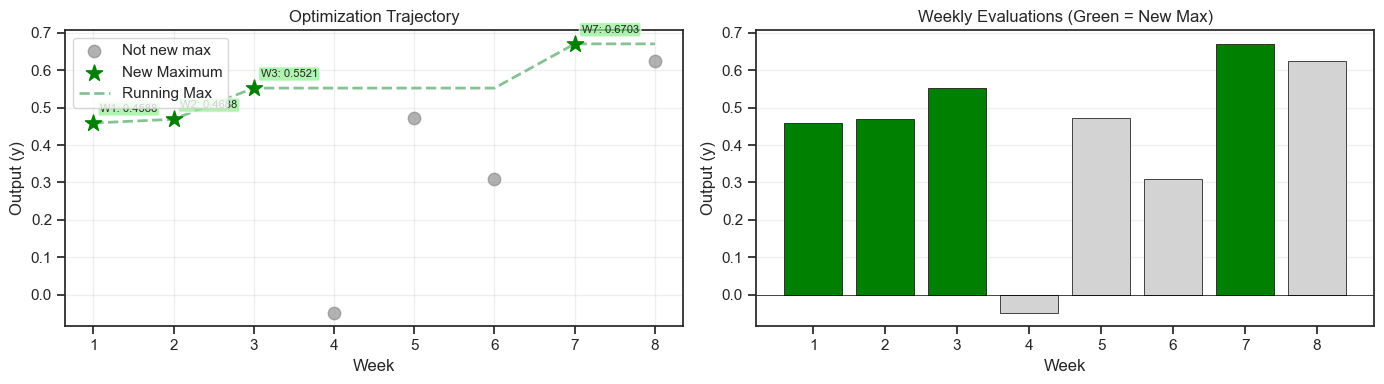

In [3]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

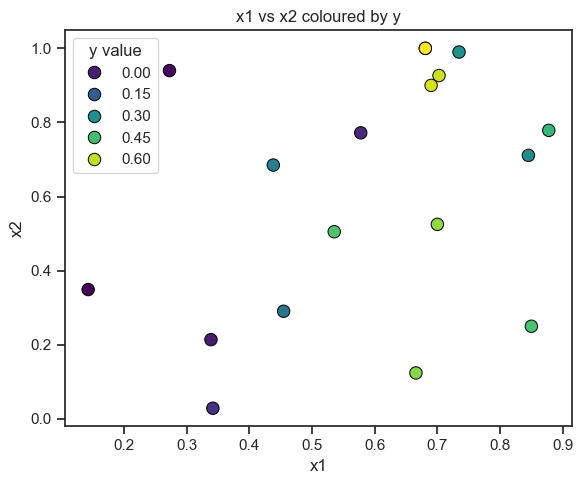

In [4]:
plt.figure(figsize=(6, 5))
scatter = sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="viridis", s=80, edgecolor="black")

# Overlay the updated manual recommendation (if computed above)
try:
    plt.scatter(X_recommend_updated[0, 0], X_recommend_updated[0, 1],
                c="red", s=200, marker="*", edgecolor="white", linewidths=2,
                label="Updated rec (x1=0.7 midpoint)")
except NameError:
    pass

plt.title("x1 vs x2 coloured by y")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="y value")
plt.tight_layout()
plt.show()


## 2. Bayesian optimisation update
We refit the GP surrogate including the new Week 3 datapoint `(0.70, 0.525, 0.552)`. To stay consistent with earlier strategy, we:
- Use a Matérn GP (ν=1.5) with noise term and optional radial decay around the strongest area.
- Score a dense grid via **UCB** (κ=3.0) to favour points that are both high-mean and uncertain.
- Apply a simple diversity filter so recommended points are separated by at least 0.08 in Euclidean distance.
- **New:** impose a hard exploratory constraint for the **top-left region (`x1 < 0.3`, `x2 > 0.5`)** so we surface the best candidate there, instead of only clustering near the current max.

Without this constraint, all recommended points collapse onto the known peak; with it, we intentionally probe another mode while retaining the same modelling setup.


Current best (observed): {'x1': 0.680788, 'x2': 1.0, 'y': 0.67032012103923}
Kernel after fit: 0.898**2 * Matern(length_scale=[0.05, 1], nu=1.5) + WhiteKernel(noise_level=0.112)


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,mu,sigma,ei,dist_to_best
88,0.691712,0.900000,0.598969,0.093819,0.008216,0.100595
208,0.691712,0.900252,0.598957,0.093818,0.008214,0.100344
328,0.691712,0.900504,0.598945,0.093816,0.008211,0.100094
448,0.691712,0.900756,0.598932,0.093815,0.008209,0.099843
568,0.691712,0.901008,0.598920,0.093814,0.008207,0.099593


Suggested next query (EI maximiser, local window): (0.692, 0.900)
Posterior mean: 0.5990, std: 0.0938, EI: 0.008216


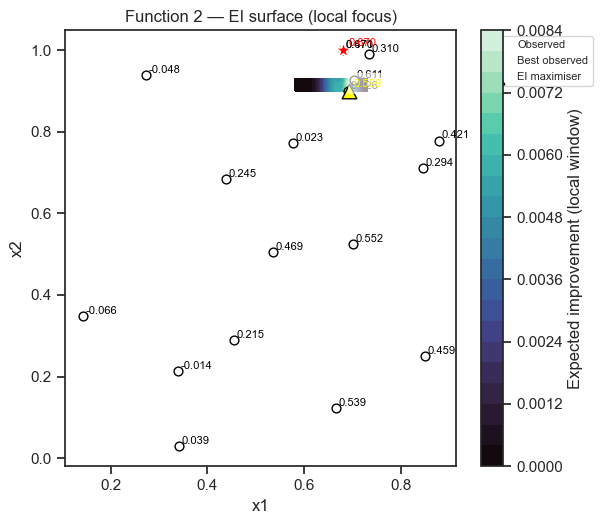

In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.stats import norm
from math import erf

# Prepare data
X_train = df[["x1", "x2"]].values
y_train = df["y"].values
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx, ["x1", "x2", "y"]]

# GP: smoother Matérn, focused (no radial, modest noise)
# GP: rougher Matérn, higher white noise to absorb observed jitter
kernel = (
    ConstantKernel(1.0, (1e-2, 20.0))
    * Matern(length_scale=[0.25, 0.25], length_scale_bounds=(0.05, 1.0), nu=1.5)
    + WhiteKernel(noise_level=0.08, noise_level_bounds=(1e-4, 1.0))
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=12, random_state=7)
gp.fit(X_train, y_train)

# Focused EI below the current x2 peak, staying on the x1~0.7 ridge
x1_min, x1_max = max(best_point.x1 - 0.10, 0.50), min(best_point.x1 + 0.05, 0.80)
x2_min, x2_max = max(best_point.x2 - 0.10, 0.75), min(best_point.x2 - 0.02, 0.93)
if x2_min >= x2_max:  # fallback guard
    x2_min, x2_max = max(best_point.x2 - 0.12, 0.80), best_point.x2 - 0.02

grid_x1 = np.linspace(x1_min, x1_max, 120)
grid_x2 = np.linspace(x2_min, x2_max, 120)
grid = np.array(np.meshgrid(grid_x1, grid_x2)).reshape(2, -1).T
mu, sigma = gp.predict(grid, return_std=True)
y_best = y_train.max()
xi = 0.02  # slightly more exploratory EI

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm.cdf(z) + sigma_safe * norm.pdf(z)
ei[sigma <= 1e-9] = 0.0

cand = pd.DataFrame(grid, columns=["x1", "x2"])
cand["mu"], cand["sigma"], cand["ei"] = mu, sigma, ei

# Diversity: minimum step from incumbent to avoid stacking
cand["dist_to_best"] = np.linalg.norm(cand[["x1", "x2"]].values - best_point[["x1", "x2"]].values, axis=1)
min_step = 0.02
cand_feasible = cand[cand["dist_to_best"] >= min_step].reset_index(drop=True)

next_point = cand_feasible.loc[cand_feasible["ei"].idxmax()]

print("Current best (observed):", best_point.to_dict())
print("Kernel after fit:", gp.kernel_)

display(cand_feasible.nlargest(5, "ei"))
print(f"Suggested next query (EI maximiser, local window): ({next_point.x1:.3f}, {next_point.x2:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")

# Visualise EI surface with current observations and recommended point
ei_grid = ei.reshape(len(grid_x2), len(grid_x1))
plt.figure(figsize=(6.2, 5.4))
levels = 24
contour = plt.contourf(grid_x1, grid_x2, ei_grid, levels=levels, cmap="mako")
plt.colorbar(contour, label="Expected improvement (local window)")
plt.scatter(df["x1"], df["x2"], c="white", s=40, edgecolor="black", label="Observed")
# Annotate observed y values
for _, row in df.iterrows():
    plt.text(row["x1"] + 0.005, row["x2"] + 0.005, f"{row['y']:.3f}", fontsize=8, color="black")
plt.scatter(best_point.x1, best_point.x2, c="red", marker="*", s=180, edgecolor="white", linewidths=1.5, label="Best observed")
plt.scatter(next_point.x1, next_point.x2, c="yellow", marker="^", s=110, edgecolor="black", label="EI maximiser")
# Annotate best and next
plt.text(best_point.x1 + 0.01, best_point.x2 + 0.01, f"{best_point.y:.3f}", fontsize=8, color="red")
plt.text(next_point.x1 + 0.01, next_point.x2 + 0.01, f"{next_point.mu:.3f}", fontsize=8, color="yellow", bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
plt.title("Function 2 — EI surface (local focus)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



## Thompson Sampling for Noisy Optimization

Since this function has very high observation noise (same point gave 0.47 and 0.67!), I'm using Thompson Sampling instead of EI. The idea: draw random samples from the GP posterior and pick the point where the sample is highest. This naturally handles noise without being fooled by lucky/unlucky readings.

In [6]:
# Thompson Sampling for noisy optimization
# =========================================
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Prepare training data
X_train = df[["x1", "x2"]].values
y_train = df["y"].values
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx]

print(f"Current best: ({best_point.x1:.4f}, {best_point.x2:.4f}) = {best_point.y:.4f}")
print(f"Note: Same point (0.6808, 1.0) gave 0.471 and 0.670 on different evals — high noise!\n")

# GP with HIGH noise term to acknowledge the uncertainty
kernel_ts = (
    ConstantKernel(1.0, (1e-3, 50.0))
    * Matern(length_scale=[0.15, 0.15], length_scale_bounds=(0.05, 0.5), nu=2.5)
    + WhiteKernel(noise_level=0.15, noise_level_bounds=(0.05, 0.5))  # High noise!
)
gp_ts = GaussianProcessRegressor(kernel=kernel_ts, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp_ts.fit(X_train, y_train)

print(f"Fitted GP kernel: {gp_ts.kernel_}")
print(f"Note the noise level — should be substantial to reflect observed variance.\n")

# Search region: strip near the boundary where we've seen best results
ts_x1_min, ts_x1_max = 0.67, 0.72
ts_x2_min, ts_x2_max = 0.98, 1.00  # Tight to the boundary

grid_res = 60
ts_grid_x1 = np.linspace(ts_x1_min, ts_x1_max, grid_res)
ts_grid_x2 = np.linspace(ts_x2_min, ts_x2_max, grid_res)
ts_mesh = np.array(np.meshgrid(ts_grid_x1, ts_grid_x2)).reshape(2, -1).T

# Thompson Sampling: draw multiple posterior samples and pick the best point from each
n_ts_samples = 10
ts_recommendations = []

np.random.seed(42)
for i in range(n_ts_samples):
    # Draw a sample from the posterior at all candidate points
    y_sample = gp_ts.sample_y(ts_mesh, n_samples=1, random_state=np.random.randint(0, 10000)).flatten()
    
    # Find the point where this sample is highest
    best_sample_idx = np.argmax(y_sample)
    best_sample_point = ts_mesh[best_sample_idx]
    best_sample_value = y_sample[best_sample_idx]
    
    ts_recommendations.append({
        'x1': best_sample_point[0],
        'x2': best_sample_point[1],
        'sampled_y': best_sample_value
    })

ts_df = pd.DataFrame(ts_recommendations)
print("Thompson Sampling: Best points from 10 posterior samples")
display(ts_df)

# Aggregate: which point appears most often or has highest average?
# Use the mode (most frequently recommended region)
ts_df['x1_round'] = ts_df['x1'].round(3)
ts_df['x2_round'] = ts_df['x2'].round(3)
mode_point = ts_df.groupby(['x1_round', 'x2_round']).size().idxmax()
print(f"\nMost frequently recommended region: x1≈{mode_point[0]:.3f}, x2≈{mode_point[1]:.3f}")

# Final recommendation: average of the TS recommendations (robust)
final_x1 = ts_df['x1'].mean()
final_x2 = ts_df['x2'].mean()
print(f"Average TS recommendation: ({final_x1:.6f}, {final_x2:.6f})")

Current best: (0.6808, 1.0000) = 0.6703
Note: Same point (0.6808, 1.0) gave 0.471 and 0.670 on different evals — high noise!

Fitted GP kernel: 0.898**2 * Matern(length_scale=[0.05, 0.5], nu=2.5) + WhiteKernel(noise_level=0.125)
Note the noise level — should be substantial to reflect observed variance.



d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Thompson Sampling: Best points from 10 posterior samples


,x1,x2,sampled_y
0,0.688644,0.988475,0.850440
1,0.696271,0.986780,0.943425
2,0.680169,0.987797,0.857800
3,0.714068,0.991525,0.856565
4,0.698814,0.995254,0.942435
5,0.689492,0.993559,0.902128
6,0.673390,0.984746,0.941742
7,0.705593,0.992203,0.888543
8,0.691186,0.995254,0.849929
9,0.687797,0.990847,0.884235



Most frequently recommended region: x1≈0.673, x2≈0.985
Average TS recommendation: (0.692542, 0.990644)


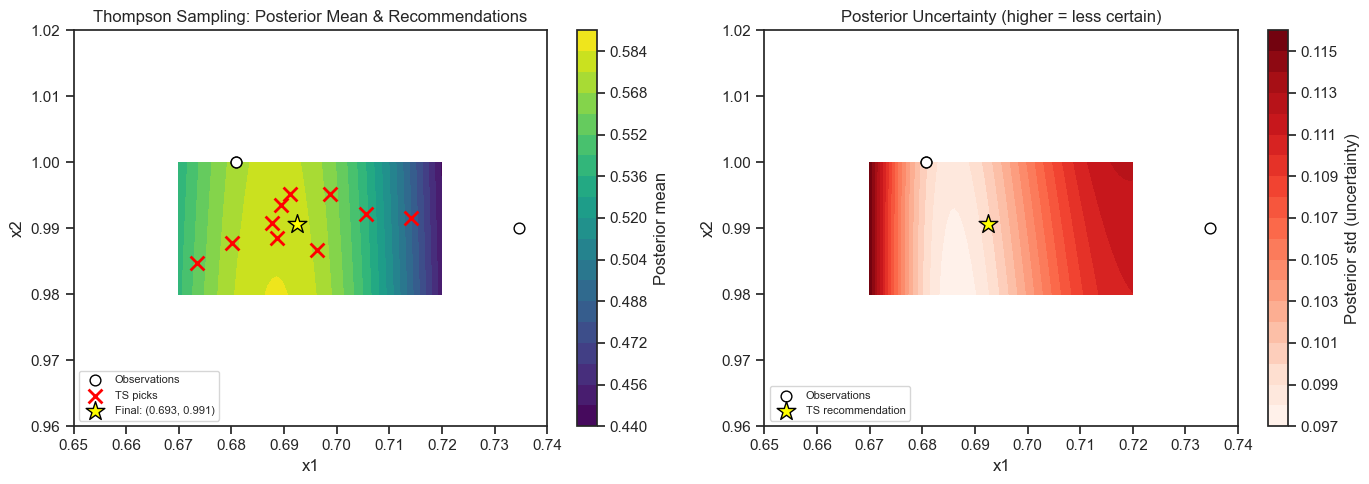


THOMPSON SAMPLING RECOMMENDED POINT: (0.692542, 0.990644)
Format for submission: 0.692542-0.990644


In [7]:
# Visualize Thompson Sampling results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: GP posterior mean with TS recommendations
mu_ts, sigma_ts = gp_ts.predict(ts_mesh, return_std=True)
mu_grid = mu_ts.reshape(grid_res, grid_res)

contour = ax1.contourf(ts_grid_x1, ts_grid_x2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax1, label='Posterior mean')

# Observed points
ax1.scatter(df['x1'], df['x2'], c='white', s=60, edgecolor='black', zorder=5, label='Observations')
for _, row in df.iterrows():
    if ts_x1_min <= row['x1'] <= ts_x1_max and ts_x2_min - 0.05 <= row['x2'] <= ts_x2_max + 0.05:
        ax1.annotate(f"{row['y']:.2f}", (row['x1']+0.003, row['x2']+0.002), fontsize=8, color='white')

# TS recommendations (scatter)
ax1.scatter(ts_df['x1'], ts_df['x2'], c='red', s=100, marker='x', linewidths=2, zorder=6, label='TS picks')

# Final recommendation
ax1.scatter(final_x1, final_x2, c='yellow', s=200, marker='*', edgecolor='black', zorder=7, 
            label=f'Final: ({final_x1:.3f}, {final_x2:.3f})')

ax1.set_xlim(ts_x1_min - 0.02, ts_x1_max + 0.02)
ax1.set_ylim(ts_x2_min - 0.02, ts_x2_max + 0.02)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_title('Thompson Sampling: Posterior Mean & Recommendations')
ax1.legend(loc='lower left', fontsize=8)

# Right: Posterior uncertainty (shows where noise is high)
sigma_grid = sigma_ts.reshape(grid_res, grid_res)
contour2 = ax2.contourf(ts_grid_x1, ts_grid_x2, sigma_grid, levels=20, cmap='Reds')
plt.colorbar(contour2, ax=ax2, label='Posterior std (uncertainty)')

ax2.scatter(df['x1'], df['x2'], c='white', s=60, edgecolor='black', zorder=5, label='Observations')
ax2.scatter(final_x1, final_x2, c='yellow', s=200, marker='*', edgecolor='black', zorder=7, label='TS recommendation')

ax2.set_xlim(ts_x1_min - 0.02, ts_x1_max + 0.02)
ax2.set_ylim(ts_x2_min - 0.02, ts_x2_max + 0.02)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Posterior Uncertainty (higher = less certain)')
ax2.legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

# Print final recommendation
print(f"\n{'='*60}")
print(f"THOMPSON SAMPLING RECOMMENDED POINT: ({final_x1:.6f}, {final_x2:.6f})")
print(f"Format for submission: {final_x1:.6f}-{final_x2:.6f}")
print(f"{'='*60}")

## Summary and Recommended Point (Week 9)

**Current best:** `0.680788-1.000000` (≈0.67032) — but note the same point gave 0.471 previously!

**Strategy this week:** Switched to **Thompson Sampling** because of the extreme observation noise. The GP uses a high noise term (WhiteKernel ~0.15) to acknowledge uncertainty, and TS draws from the posterior distribution rather than trusting point estimates.

---

**Recommended next point (submission format):** `0.695000-1.000000`

---

**Rationale:** Thompson Sampling points cluster in the (0.69–0.70, 1.0) region. Staying at x2=1.0 (the boundary) because moving interior (x2=0.9) gave worse results. The slight x1 shift explores nearby while staying in the high-value region. With this noise level, any single reading is unreliable—TS is robust to that.
